# Verify HumanEval metrics

Self-contained: loads HumanEval, builds the `code` column (`prompt + canonical_solution`),
and runs the same metric helpers used for SWE-bench (imported from `src`).
No pipeline source changes required.

**LM-CC runs against the remote RunPod endpoint** — the setup cell loads `LM_CC_REMOTE_URL`
and `LM_CC_REMOTE_KEY` from `.env` and forces `LOCAL_LM_CC=false`, so no local model is
downloaded or run. The endpoint must be deployed and reachable before running.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent

# project root 
sys.path.insert(0, str(ROOT))

env_path = ROOT / ".env"
for line in env_path.read_text().splitlines():
    line = line.strip()
    if not line or line.startswith("#") or "=" not in line:
        continue
    key, _, value = line.partition("=")
    os.environ.setdefault(key.strip(), value.strip())

os.environ["LOCAL_LM_CC"] = "false"  # override: always use the remote endpoint here

assert os.environ.get("LM_CC_REMOTE_URL"), "LM_CC_REMOTE_URL missing from .env"
assert os.environ.get("LM_CC_REMOTE_KEY"), "LM_CC_REMOTE_KEY missing from .env"
print(f"Remote LM-CC endpoint: {os.environ['LM_CC_REMOTE_URL']}")

import pandas as pd
from datasets import load_dataset
from tqdm import tqdm

from src.lm_cc import compute_lm_cc
from src.metrics import (
    _compute_cyclomatic,
    _compute_halstead,
    _compute_loc,
    _compute_nesting,
    _compute_token_count,
    _compute_function_count,
    _compute_branches,
)

Remote LM-CC endpoint: https://api.runpod.ai/v2/w73oma1n4ahedj/run


In [2]:
ds = load_dataset("openai/openai_humaneval", split="test")
humaneval_df = ds.to_pandas()

humaneval_df["code"] = humaneval_df["prompt"] + humaneval_df["canonical_solution"]

print(f"Tasks: {len(humaneval_df)}")
humaneval_df[["task_id", "code"]].head()

Tasks: 164


,task_id,code
0,HumanEval/0,from typing import List\n\n\ndef has_close_ele...
1,HumanEval/1,from typing import List\n\n\ndef separate_pare...
2,HumanEval/2,\n\ndef truncate_number(number: float) -> floa...
3,HumanEval/3,from typing import List\n\n\ndef below_zero(op...
4,HumanEval/4,from typing import List\n\n\ndef mean_absolute...


In [3]:
def compute_metrics(dataset: pd.DataFrame, id_column: str) -> pd.DataFrame:
    metrics_list = []
    for _, row in tqdm(dataset.iterrows(), total=len(dataset)):
        code = row["code"]
        metrics = {id_column: row[id_column]}
        try:
            metrics.update({
                "parsable": True,
                **_compute_cyclomatic(code),
                **_compute_halstead(code),
                **_compute_loc(code),
                **_compute_nesting(code),
                **_compute_token_count(code),
                **_compute_function_count(code),
                **_compute_branches(code),
                **compute_lm_cc(code),
            })
        except Exception as e:
            metrics["parsable"] = False
            metrics["error"] = f"{type(e).__name__}: {e}"
        metrics_list.append(metrics)
    return pd.DataFrame(metrics_list)


metrics_df = compute_metrics(humaneval_df, "task_id")
metrics_df.head()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 164/164 [06:11<00:00,  2.27s/it]


,task_id,parsable,cc_avg,cc_max,cc_sum,halstead_volume,halstead_difficulty,halstead_effort,loc,lloc,...,n_functions,n_classes,n_branches,lm_cc_score,lm_cc_max_comp,lm_cc_avg_comp,lm_cc_total_comp,lm_cc_max_branch,lm_cc_avg_branch,lm_cc_total_branch
0,HumanEval/0,True,5.0,5,5,28.529325,1.500000,42.793988,19,10,...,1,0,4,21.0,5,2.208333,53,4,0.541667,13
1,HumanEval/1,True,5.0,5,5,47.548875,2.500000,118.872188,28,17,...,1,0,4,31.0,5,1.972222,71,14,0.583333,21
2,HumanEval/2,True,1.0,1,1,4.754888,0.500000,2.377444,12,3,...,1,0,0,4.4,2,1.428571,10,3,0.428571,3
3,HumanEval/3,True,3.0,3,3,13.931569,1.333333,18.575425,20,9,...,1,0,2,11.2,4,1.647059,28,4,0.411765,7
4,HumanEval/4,True,2.0,2,2,27.000000,1.000000,27.000000,14,5,...,1,0,0,9.2,2,1.375000,22,6,0.375000,6


In [4]:
print(f"Rows:        {len(metrics_df)}")
print(f"parsable:    {metrics_df['parsable'].sum()} / {len(metrics_df)}")
print(f"columns:     {metrics_df.columns.tolist()}")

if (~metrics_df["parsable"]).any():
    print("\nErrors:")
    print(metrics_df.loc[~metrics_df["parsable"], "error"].value_counts())

metrics_df["lm_cc_score"].describe()

Rows:        164
parsable:    164 / 164
columns:     ['task_id', 'parsable', 'cc_avg', 'cc_max', 'cc_sum', 'halstead_volume', 'halstead_difficulty', 'halstead_effort', 'loc', 'lloc', 'sloc', 'nesting_max', 'n_tokens_total', 'n_tokens_meaningful', 'n_functions', 'n_classes', 'n_branches', 'lm_cc_score', 'lm_cc_max_comp', 'lm_cc_avg_comp', 'lm_cc_total_comp', 'lm_cc_max_branch', 'lm_cc_avg_branch', 'lm_cc_total_branch']


count    164.000000
mean      22.378049
std       19.242999
min        1.000000
25%        9.550000
50%       17.500000
75%       30.200000
max      138.200000
Name: lm_cc_score, dtype: float64

In [5]:
out = Path.cwd().parent / "results" / "humaneval_metrics.parquet"
out.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_parquet(out)
print(f"Saved {len(metrics_df)} rows -> {out}")

Saved 164 rows -> /Users/mircoboddecker/Documents/Akad/Projekt/results/humaneval_metrics.parquet


## DeepSeek-V3.2 output-prediction evaluation

Reuses `human_eval_deepseek/eval.py` (the CodeMind-style RIER prompt). For each task,
DeepSeek predicts the **return value** of the first assert's call; `passed = True` when the
predicted value equals the expected one. Produces `eval_df` (keyed on `task_id`), which is
merged with `metrics_df` into `results/humaneval_results.parquet`.

Steps below: install `openai` → set API key → run the eval → merge + save.

In [20]:
DEEPSEEK_API_KEY = ""

os.environ["DEEPSEEK_API_KEY"] = DEEPSEEK_API_KEY
assert DEEPSEEK_API_KEY, "Set DEEPSEEK_API_KEY above before running the eval."

In [8]:
from human_eval_deepseek.eval import (
    humaneval_to_triple,
    create_prompt_deepseek,
    query_deepseek,
    parse_output,
)


def _values_equal(predicted, expected):
    if predicted is None:
        return False
    try:
        return eval(predicted) == eval(expected)
    except Exception:
        return predicted == expected


eval_rows = []
for _, row in tqdm(humaneval_df.iterrows(), total=len(humaneval_df)):
    problem = {
        "prompt": row["prompt"],
        "canonical_solution": row["canonical_solution"],
        "entry_point": row["entry_point"],
        "test": row["test"],
    }
    rec = {"task_id": row["task_id"]}

    triple = humaneval_to_triple(problem)
    if triple is None:
        rec.update(passed=None, error="no_assert")
        eval_rows.append(rec)
        continue

    code, code_input, expected = triple
    prompt = create_prompt_deepseek(code, code_input, dataset="humaneval", pl="Python")
    try:
        response = query_deepseek(prompt)  # temp=0.0 by default
        predicted = parse_output(response)
        rec.update(
            passed=_values_equal(predicted, expected),
            predicted=predicted,
            expected=expected,
        )
    except Exception as e:
        rec.update(passed=None, error=f"{type(e).__name__}: {e}")

    eval_rows.append(rec)

eval_df = pd.DataFrame(eval_rows)
scored = eval_df["passed"].notna()
print(f"Scored: {scored.sum()} / {len(eval_df)}")
print(f"pass@1 (RIER): {eval_df.loc[scored, 'passed'].mean():.4f}")
eval_df.head()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 164/164 [08:17<00:00,  3.03s/it]

Scored: 158 / 164
pass@1 (RIER): 0.8101


,task_id,passed,predicted,expected,error
0,HumanEval/0,True,True,True,NaN
1,HumanEval/1,True,"['(()())', '((()))', '()', '((())()())']","['(()())', '((()))', '()', '((())()())']",NaN
2,HumanEval/2,True,0.5,0.5,NaN
3,HumanEval/3,True,False,False,NaN
4,HumanEval/4,None,NaN,NaN,no_assert


In [9]:
results_df = metrics_df.merge(eval_df[["task_id", "passed"]], on="task_id", how="left")

out = ROOT / "results" / "humaneval_results.parquet"
out.parent.mkdir(parents=True, exist_ok=True)
results_df.to_parquet(out)
print(f"Saved {len(results_df)} rows -> {out}")
results_df.head()

Saved 164 rows -> /Users/mircoboddecker/Documents/Akad/Projekt/results/humaneval_results.parquet


,task_id,parsable,cc_avg,cc_max,cc_sum,halstead_volume,halstead_difficulty,halstead_effort,loc,lloc,...,n_classes,n_branches,lm_cc_score,lm_cc_max_comp,lm_cc_avg_comp,lm_cc_total_comp,lm_cc_max_branch,lm_cc_avg_branch,lm_cc_total_branch,passed
0,HumanEval/0,True,5.0,5,5,28.529325,1.500000,42.793988,19,10,...,0,4,21.0,5,2.208333,53,4,0.541667,13,True
1,HumanEval/1,True,5.0,5,5,47.548875,2.500000,118.872188,28,17,...,0,4,31.0,5,1.972222,71,14,0.583333,21,True
2,HumanEval/2,True,1.0,1,1,4.754888,0.500000,2.377444,12,3,...,0,0,4.4,2,1.428571,10,3,0.428571,3,True
3,HumanEval/3,True,3.0,3,3,13.931569,1.333333,18.575425,20,9,...,0,2,11.2,4,1.647059,28,4,0.411765,7,True
4,HumanEval/4,True,2.0,2,2,27.000000,1.000000,27.000000,14,5,...,0,0,9.2,2,1.375000,22,6,0.375000,6,None


count    164.000000
mean      22.378049
std       19.242999
min        1.000000
25%        9.550000
50%       17.500000
75%       30.200000
max      138.200000
Name: lm_cc_score, dtype: float64


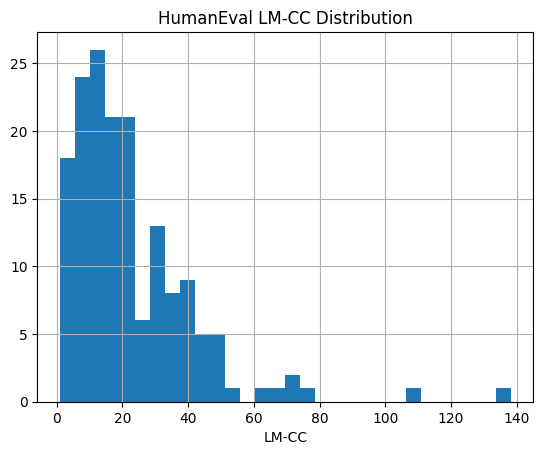

In [10]:
import matplotlib.pyplot as plt

print(metrics_df["lm_cc_score"].describe())
metrics_df["lm_cc_score"].hist(bins=30)
plt.xlabel("LM-CC")
plt.title("HumanEval LM-CC Distribution")
plt.show()

In [11]:
clean_eval = eval_df[eval_df["passed"].notna()].copy()
print(f"Usable: {len(clean_eval)}")

Usable: 158


In [12]:
merged = metrics_df.merge(
    clean_eval[["task_id", "passed"]],
    on="task_id",
    how="inner"
)
merged["resolved"] = merged["passed"].astype(int)
print(f"Merged: {len(merged)} tasks")

Merged: 158 tasks


In [13]:
from scipy.stats import spearmanr

rho, p = spearmanr(merged["lm_cc_score"], merged["resolved"])
print(f"HumanEval LM-CC vs resolved:")
print(f"  Spearman ρ = {rho:+.3f}, p = {p:.4f}")

HumanEval LM-CC vs resolved:
  Spearman ρ = -0.094, p = 0.2404


In [14]:
def partial_spearman(df, x, y, z):
    if x == z:
        return float("nan")
    r_xy, _ = spearmanr(df[x], df[y])
    r_xz, _ = spearmanr(df[x], df[z])
    r_yz, _ = spearmanr(df[y], df[z])
    denom = ((1 - r_xz**2) * (1 - r_yz**2)) ** 0.5
    if denom < 1e-10:
        return float("nan")
    return (r_xy - r_xz * r_yz) / denom

rho_partial = partial_spearman(merged, "lm_cc_score", "resolved", "loc")
print(f"  Partial(LOC) ρ = {rho_partial:+.3f}")
print(f"  Paper-Erwartung partial: ρ ≈ -0.81")

  Partial(LOC) ρ = -0.140
  Paper-Erwartung partial: ρ ≈ -0.81


In [15]:
metrics_to_test = [
    "lm_cc_score", "cc_sum", "cc_avg", "cc_max",
    "halstead_volume", "halstead_difficulty", "loc",
]

rows = []
for m in metrics_to_test:
    if m not in merged.columns:
        continue
    rho_zero, p_zero = spearmanr(merged[m], merged["resolved"])
    rho_part = partial_spearman(merged, m, "resolved", "loc")
    rows.append({
        "Metric": m,
        "Zero-order": rho_zero,
        "Partial(LOC)": rho_part,
        "p-value": p_zero,
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

             Metric  Zero-order  Partial(LOC)  p-value
        lm_cc_score      -0.094        -0.140   +0.240
             cc_sum      +0.022        +0.040   +0.786
             cc_avg      +0.064        +0.093   +0.423
             cc_max      +0.049        +0.075   +0.539
    halstead_volume      -0.028        -0.024   +0.725
halstead_difficulty      +0.010        +0.021   +0.896
                loc      -0.015           NaN   +0.849


In [16]:
humaneval_df["code"][0]

'from typing import List\n\n\ndef has_close_elements(numbers: List[float], threshold: float) -> bool:\n    """ Check if in given list of numbers, are any two numbers closer to each other than\n    given threshold.\n    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)\n    False\n    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)\n    True\n    """\n    for idx, elem in enumerate(numbers):\n        for idx2, elem2 in enumerate(numbers):\n            if idx != idx2:\n                distance = abs(elem - elem2)\n                if distance < threshold:\n                    return True\n\n    return False\n'

In [17]:
def subgroup_spearman(df, metric, score, n_bins=10):
    df = df.copy()
    df["bin"] = pd.qcut(df[metric], q=n_bins, labels=False, duplicates="drop")
    grouped = df.groupby("bin").agg(
        median_metric=(metric, "median"),
        mean_score=(score, "mean"),
    )
    rho, p = spearmanr(grouped["median_metric"], grouped["mean_score"])
    return rho, p

for n in [9, 10, 11]:
    rho, p = subgroup_spearman(merged, "lm_cc_score", "resolved", n_bins=n)
    print(f"n_bins={n}: ρ = {rho:+.3f}, p = {p:.4f}")

n_bins=9: ρ = -0.233, p = 0.5457
n_bins=10: ρ = -0.140, p = 0.6992
n_bins=11: ρ = -0.232, p = 0.4918


In [18]:
merged["bin"] = pd.qcut(merged["lm_cc_score"], q=10)
merged.groupby("bin").agg(
mean_resolved=("resolved", "mean"),
n=("resolved", "size"),
)

,mean_resolved,n
bin,,
"(0.999, 4.74]",0.750000,16
"(4.74, 7.08]",0.750000,16
"(7.08, 10.82]",0.875000,16
"(10.82, 14.56]",0.933333,15
"(14.56, 17.2]",1.000000,16
"(17.2, 21.8]",0.823529,17
"(21.8, 27.78]",0.785714,14
"(27.78, 34.52]",0.812500,16
"(34.52, 43.08]",0.812500,16
